In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv('Dataset_spine.csv')

In [3]:
df.shape

(310, 7)

In [4]:
df.head()

,pelvic incidence,pelvic tilt,lumbar lordosis angle,sacral slope,pelvic radius,grade of spondylolisthesis,Class_att
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,Abnormal
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Abnormal
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Abnormal
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Abnormal
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Abnormal


In [5]:
df.tail()

,pelvic incidence,pelvic tilt,lumbar lordosis angle,sacral slope,pelvic radius,grade of spondylolisthesis,Class_att
305,47.903565,13.616688,36.000000,34.286877,117.449062,-4.245395,Normal
306,53.936748,20.721496,29.220534,33.215251,114.365845,-0.421010,Normal
307,61.446597,22.694968,46.170347,38.751628,125.670725,-2.707880,Normal
308,45.252792,8.693157,41.583126,36.559635,118.545842,0.214750,Normal
309,33.841641,5.073991,36.641233,28.767649,123.945244,-0.199249,Normal


In [6]:
df.isnull().sum()

pelvic incidence               0
 pelvic tilt                   0
 lumbar lordosis angle         0
 sacral slope                  0
 pelvic radius                 0
 grade of spondylolisthesis    0
Class_att                      0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   pelvic incidence             310 non-null    float64
 1    pelvic tilt                 310 non-null    float64
 2    lumbar lordosis angle       310 non-null    float64
 3    sacral slope                310 non-null    float64
 4    pelvic radius               310 non-null    float64
 5    grade of spondylolisthesis  310 non-null    float64
 6   Class_att                    310 non-null    object 
dtypes: float64(6), object(1)
memory usage: 17.1+ KB


In [8]:
df.describe()

,pelvic incidence,pelvic tilt,lumbar lordosis angle,sacral slope,pelvic radius,grade of spondylolisthesis
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000
mean,60.496653,17.542822,51.930930,42.953831,117.920655,26.296694
std,17.236520,10.008330,18.554064,13.423102,13.317377,37.559027
min,26.147921,-6.554948,14.000000,13.366931,70.082575,-11.058179
25%,46.430294,10.667069,37.000000,33.347122,110.709196,1.603727
50%,58.691038,16.357689,49.562398,42.404912,118.268178,11.767934
75%,72.877696,22.120395,63.000000,52.695888,125.467674,41.287352
max,129.834041,49.431864,125.742385,121.429566,163.071041,418.543082


In [9]:
df['Class_att'] = df['Class_att'].map({'Normal': 0, 'Abnormal': 1})

In [10]:
df.head()

,pelvic incidence,pelvic tilt,lumbar lordosis angle,sacral slope,pelvic radius,grade of spondylolisthesis,Class_att
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,1
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,1
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,1
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,1
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,1


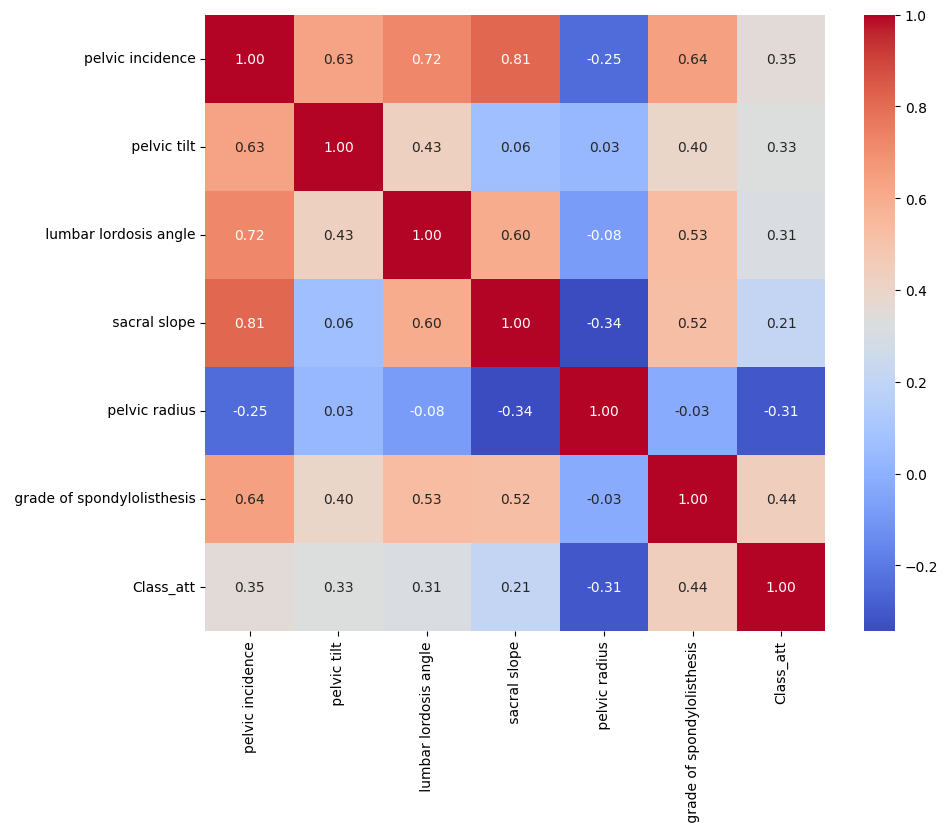

In [11]:

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

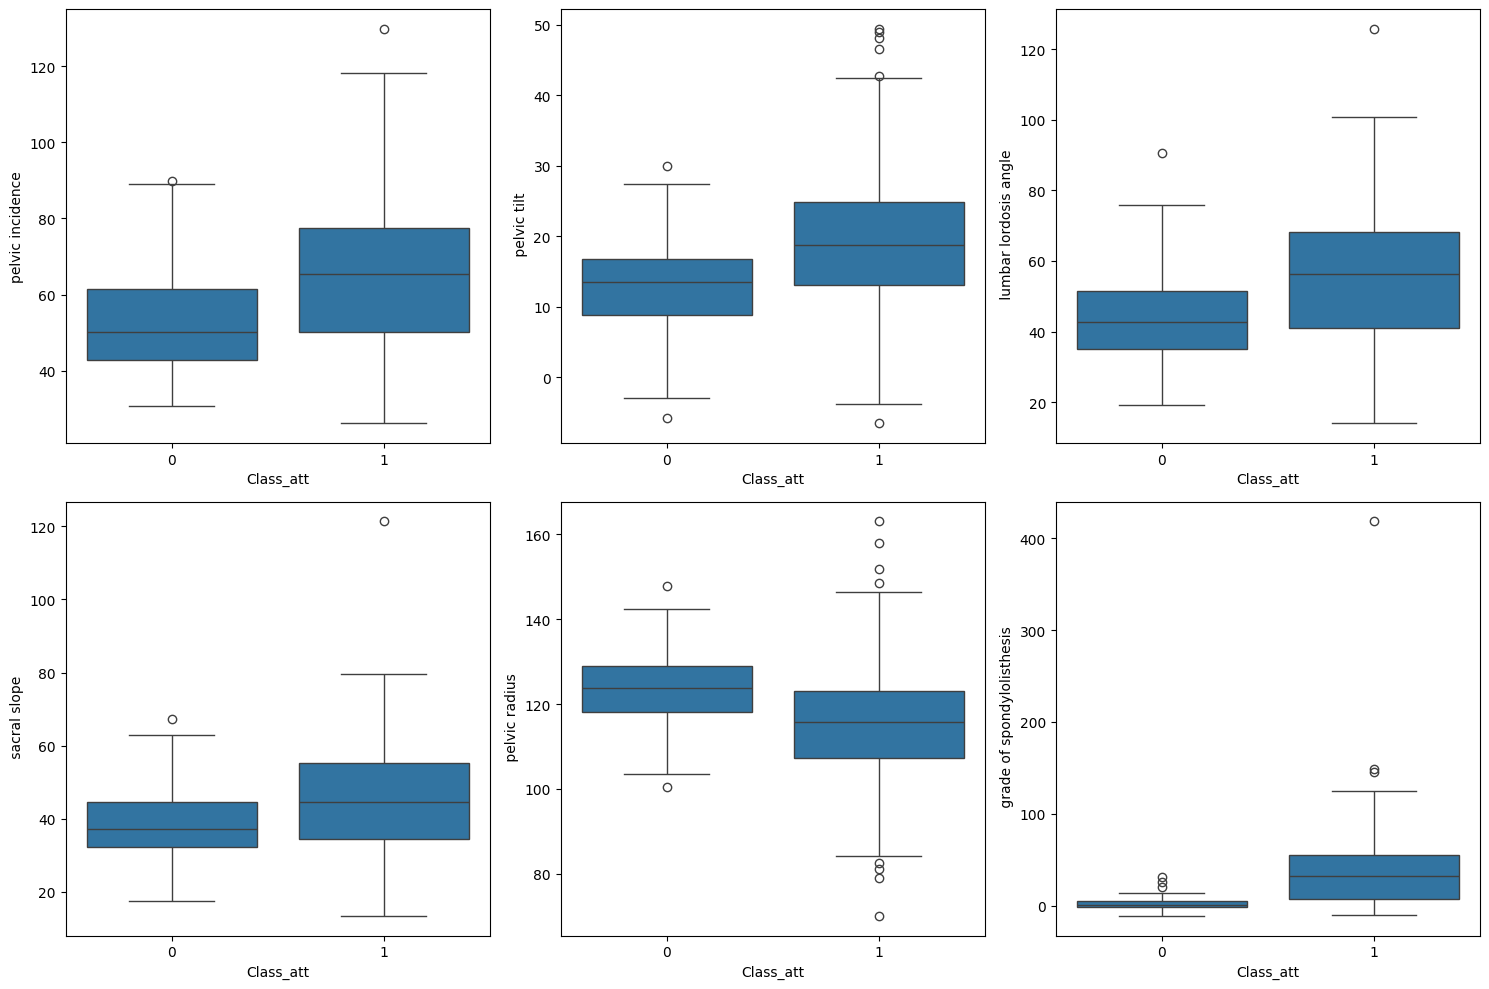

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features = [c for c in df.columns if c != 'Class_att']
for ax, col in zip(axes.flatten(), features):
    sns.boxplot(x='Class_att', y=col, data=df, ax=ax)
plt.tight_layout()
plt.show()


In [13]:
X = df.drop('Class_att', axis=1)
y = df['Class_att']

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
param_grid_rf = {
    'n_estimators': [100, 300, 500, 700],
    'max_depth': [10, 15, 20, 25], 
    'min_samples_split': [5, 10, 15], 
    'min_samples_leaf': [2, 4, 6, 8]    
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=3,
    scoring='f1',
    verbose=2, 
    n_jobs=-1
)

grid_rf.fit(X_treino, y_treino)

print(f"Melhores Parâmetros RF: {grid_rf.best_params_}")

Fitting 3 folds for each of 192 candidates, totalling 576 fits
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   0.2s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   0.2s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   0.2s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=   0.7s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=   0.7s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=   0.7s
[CV] END max_depth=10, mi

F1 Score Random Forest: 84.78%
Taxa de Erro: 22.58%



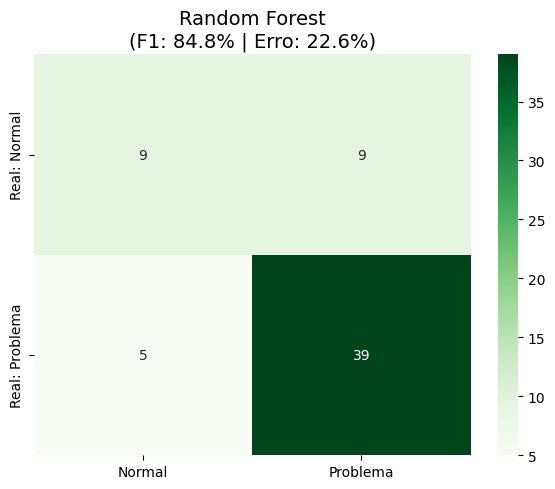

In [15]:
modelo = RandomForestClassifier(**grid_rf.best_params_, random_state=42, n_jobs=-1)

modelo.fit(X_treino, y_treino)

previsoes = modelo.predict(X_teste)

f1 = f1_score(y_teste, previsoes)
acc = accuracy_score(y_teste, previsoes)
print(f"F1 Score Random Forest: {f1 * 100:.2f}%")
print(f"Taxa de Erro: {(1 - acc) * 100:.2f}%\n")

plt.figure(figsize=(6, 5))
matriz_rf = confusion_matrix(y_teste, previsoes)
sns.heatmap(matriz_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Problema'], yticklabels=['Real: Normal', 'Real: Problema'])
plt.title(f'Random Forest\n(F1: {f1*100:.1f}% | Erro: {(1-acc)*100:.1f}%)', fontsize=14)
plt.tight_layout()
plt.show()


In [16]:
param_grid_xgb = {
    'n_estimators': [100, 300, 500, 700],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.5],
    'subsample': [0.8, 1.0, 1.2],
    'colsample_bytree': [0.8, 1.0, 1.2] 
}

xgb_base = XGBClassifier(tree_method='hist', random_state=42, n_jobs=-1)

grid_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='f1',
    verbose=2,
    n_jobs=-1
)

grid_xgb.fit(X_treino, y_treino)

print(f"Melhores Parâmetros XGB: {grid_xgb.best_params_}")

Fitting 3 folds for each of 720 candidates, totalling 2160 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=300, subsample=1.2; total time=   3.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=300, subsample=1.2; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=300, subsample=1.2; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.8; total time=   3.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.8; total time=   3.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=1.2; total time=   3.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=1.2; total time=   3.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=1.0; total time=   3.3s
[CV] END

/home/vcollares/.venv/lib64/python3.12/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
1200 fits failed out of a total of 2160.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
480 fits failed with the following error:
Traceback (most recent call last):
  File "/home/vcollares/.venv/lib64/python3.12/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/vcollares/.venv/lib64/python3.12/site-packages/xgboost/core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/home/vcollares/.venv/lib64/python3.12/site-packages/xgboost/sklearn.py", line 1806, in fit
    self._Booster = train(
      

Melhores Parâmetros XGB: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}


F1 Score XGBoost: 88.89%
Taxa de Erro: 16.13%



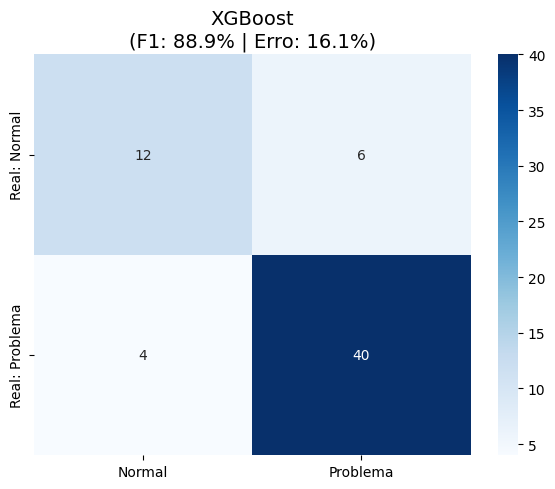

In [17]:
modelo_xgb_final = XGBClassifier(**grid_xgb.best_params_, random_state=42, n_jobs=-1)

modelo_xgb_final.fit(X_treino, y_treino)

previsoes_xgb = modelo_xgb_final.predict(X_teste)

f1_xgb = f1_score(y_teste, previsoes_xgb)
acc_xgb = accuracy_score(y_teste, previsoes_xgb)
print(f"F1 Score XGBoost: {f1_xgb * 100:.2f}%")
print(f"Taxa de Erro: {(1 - acc_xgb) * 100:.2f}%\n")

plt.figure(figsize=(6, 5))
matriz_xgb = confusion_matrix(y_teste, previsoes_xgb)
sns.heatmap(matriz_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Problema'], yticklabels=['Real: Normal', 'Real: Problema'])
plt.title(f'XGBoost\n(F1: {f1_xgb*100:.1f}% | Erro: {(1-acc_xgb)*100:.1f}%)', fontsize=14)
plt.tight_layout()
plt.show()


In [18]:
# --- Análise de Overfitting: Treino vs Teste ---

# Predições no conjunto de TREINO
prev_treino_rf  = modelo.predict(X_treino)
prev_treino_xgb = modelo_xgb_final.predict(X_treino)

# Ambos usam average='binary' (padrão) — igual às células de treinamento
f1_treino_rf   = f1_score(y_treino, prev_treino_rf)
acc_treino_rf  = accuracy_score(y_treino, prev_treino_rf)
f1_treino_xgb  = f1_score(y_treino, prev_treino_xgb)
acc_treino_xgb = accuracy_score(y_treino, prev_treino_xgb)

# Scores de teste — recalculados para consistência
f1_teste_rf   = f1_score(y_teste, previsoes)
acc_teste_rf  = accuracy_score(y_teste, previsoes)
f1_teste_xgb  = f1_score(y_teste, previsoes_xgb)
acc_teste_xgb = accuracy_score(y_teste, previsoes_xgb)

print('=' * 52)
print(f'{'':>20} {'TREINO':>10} {'TESTE':>10}')
print('=' * 52)
print(f'{'RF  — F1 Score':>20} {f1_treino_rf*100:>9.2f}% {f1_teste_rf*100:>9.2f}%')
print(f'{'RF  — Acurácia':>20} {acc_treino_rf*100:>9.2f}% {acc_teste_rf*100:>9.2f}%')
print('-' * 52)
print(f'{'XGB — F1 Score':>20} {f1_treino_xgb*100:>9.2f}% {f1_teste_xgb*100:>9.2f}%')
print(f'{'XGB — Acurácia':>20} {acc_treino_xgb*100:>9.2f}% {acc_teste_xgb*100:>9.2f}%')
print('=' * 52)
print()
print(f'Diferença RF  (treino - teste) F1:  {(f1_treino_rf  - f1_teste_rf)*100:+.2f}%')
print(f'Diferença XGB (treino - teste) F1:  {(f1_treino_xgb - f1_teste_xgb)*100:+.2f}%')
print()
print('Interpretação:')
print('  Diferença pequena (< 5%)  => modelo generaliza bem (sem overfitting)')
print('  Diferença grande  (> 10%) => possível overfitting')


                         TREINO      TESTE
      RF  — F1 Score     97.04%     84.78%
      RF  — Acurácia     95.97%     77.42%
----------------------------------------------------
      XGB — F1 Score     97.92%     88.89%
      XGB — Acurácia     97.18%     83.87%

Diferença RF  (treino - teste) F1:  +12.26%
Diferença XGB (treino - teste) F1:  +9.03%

Interpretação:
  Diferença pequena (< 5%)  => modelo generaliza bem (sem overfitting)
  Diferença grande  (> 10%) => possível overfitting
